In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="pastel")


import gc # for garbadge collection

### loading data 


In [3]:
df_train = pd.read_csv(r'C:\Users\hasan\RAFI_SAA\github_repos\fantastic-pancake\data\home-credit-default-risk\application_train.csv')

In [4]:
df_train.head(6)

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
5,100008,0,Cash loans,M,N,Y,0,99000.0,490495.5,27517.5,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,1.0


In [5]:
print('there are '+ str(df_train.shape[1]) + ' columns \n' )
print('There are ' + str(df_train.shape[0])+ ' rows \n') 

there are 122 columns 

There are 307511 rows 



In [6]:
test_df = pd.read_csv(r"C:\Users\hasan\RAFI_SAA\github_repos\fantastic-pancake\data\home-credit-default-risk\application_test.csv")
test_df

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100001,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,450000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
1,100005,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,180000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
2,100013,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,630000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,4.0
3,100028,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,1575000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
4,100038,Cash loans,M,Y,N,1,180000.0,625500.0,32067.0,625500.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48739,456221,Cash loans,F,N,Y,0,121500.0,412560.0,17473.5,270000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
48740,456222,Cash loans,F,N,N,2,157500.0,622413.0,31909.5,495000.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
48741,456223,Cash loans,F,Y,Y,1,202500.0,315000.0,33205.5,315000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,3.0,1.0
48742,456224,Cash loans,M,N,N,0,225000.0,450000.0,25128.0,450000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,2.0


### Analyzing the distribution of Target field!!

In [7]:
df_train['TARGET'].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

<Axes: xlabel='TARGET', ylabel='count'>

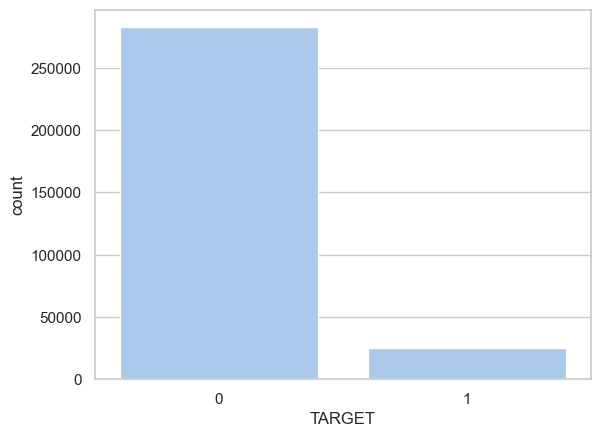

In [8]:
sns.countplot(x='TARGET', data=df_train)

Next step : Correlation of features to check which feature is more related to each other . it will help undestand which feature will have more impact on the learning of the model!

In [9]:
numeric_df = df_train.select_dtypes(include=['float64', 'int64'])
corr = numeric_df.corr()['TARGET'].sort_values()

print('Top positive correlations:\n', corr.tail(15))
print('\nTop negative correlations:\n', corr.head(15))


Top positive correlations:
 DEF_60_CNT_SOCIAL_CIRCLE       0.031276
DEF_30_CNT_SOCIAL_CIRCLE       0.032248
LIVE_CITY_NOT_WORK_CITY        0.032518
OWN_CAR_AGE                    0.037612
DAYS_REGISTRATION              0.041975
FLAG_DOCUMENT_3                0.044346
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_EMP_PHONE                 0.045982
REG_CITY_NOT_WORK_CITY         0.050994
DAYS_ID_PUBLISH                0.051457
DAYS_LAST_PHONE_CHANGE         0.055218
REGION_RATING_CLIENT           0.058899
REGION_RATING_CLIENT_W_CITY    0.060893
DAYS_BIRTH                     0.078239
TARGET                         1.000000
Name: TARGET, dtype: float64

Top negative correlations:
 EXT_SOURCE_3                 -0.178919
EXT_SOURCE_2                 -0.160472
EXT_SOURCE_1                 -0.155317
DAYS_EMPLOYED                -0.044932
FLOORSMAX_AVG                -0.044003
FLOORSMAX_MEDI               -0.043768
FLOORSMAX_MODE               -0.043226
AMT_GOODS_PRICE              -0.039645
RE

#### unpacking the text fields and analyzing the data

In [10]:
text_fields = df_train.select_dtypes(include=['object']).columns
text_fields

Index(['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE',
       'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE',
       'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE'],
      dtype='str')

In [11]:
df_train[text_fields].head()


,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,OCCUPATION_TYPE,WEEKDAY_APPR_PROCESS_START,ORGANIZATION_TYPE,FONDKAPREMONT_MODE,HOUSETYPE_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE
0,Cash loans,M,N,Y,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,Laborers,WEDNESDAY,Business Entity Type 3,reg oper account,block of flats,"Stone, brick",No
1,Cash loans,F,N,N,Family,State servant,Higher education,Married,House / apartment,Core staff,MONDAY,School,reg oper account,block of flats,Block,No
2,Revolving loans,M,Y,Y,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,Laborers,MONDAY,Government,NaN,NaN,NaN,NaN
3,Cash loans,F,N,Y,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,Laborers,WEDNESDAY,Business Entity Type 3,NaN,NaN,NaN,NaN
4,Cash loans,M,N,Y,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,Core staff,THURSDAY,Religion,NaN,NaN,NaN,NaN


In [12]:
# counting the unique values of each columns 
for col in text_fields:
    print(col, " --> ", df_train[col].unique(), "Unique values")

NAME_CONTRACT_TYPE  -->  <StringArray>
['Cash loans', 'Revolving loans']
Length: 2, dtype: str Unique values
CODE_GENDER  -->  <StringArray>
['M', 'F', 'XNA']
Length: 3, dtype: str Unique values
FLAG_OWN_CAR  -->  <StringArray>
['N', 'Y']
Length: 2, dtype: str Unique values
FLAG_OWN_REALTY  -->  <StringArray>
['Y', 'N']
Length: 2, dtype: str Unique values
NAME_TYPE_SUITE  -->  <StringArray>
[  'Unaccompanied',          'Family', 'Spouse, partner',        'Children',
         'Other_A',               nan,         'Other_B', 'Group of people']
Length: 8, dtype: str Unique values
NAME_INCOME_TYPE  -->  <StringArray>
[             'Working',        'State servant', 'Commercial associate',
            'Pensioner',           'Unemployed',              'Student',
          'Businessman',      'Maternity leave']
Length: 8, dtype: str Unique values
NAME_EDUCATION_TYPE  -->  <StringArray>
['Secondary / secondary special',              'Higher education',
             'Incomplete higher',        

In [13]:
df_train.nunique().sort_values()

TARGET                     2
NAME_CONTRACT_TYPE         2
FLAG_OWN_REALTY            2
FLAG_OWN_CAR               2
FLAG_WORK_PHONE            2
                       ...  
DAYS_REGISTRATION      15688
DAYS_BIRTH             17460
EXT_SOURCE_1          114584
EXT_SOURCE_2          119831
SK_ID_CURR            307511
Length: 122, dtype: int64

In [12]:
print("This is till EDA v2")

This is till EDA v2


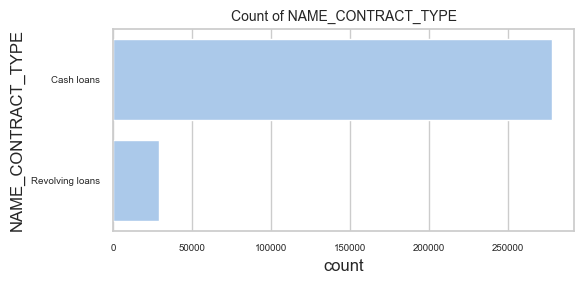

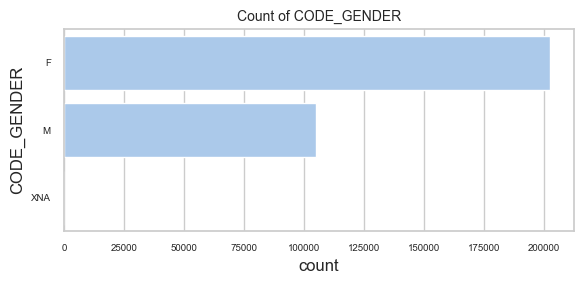

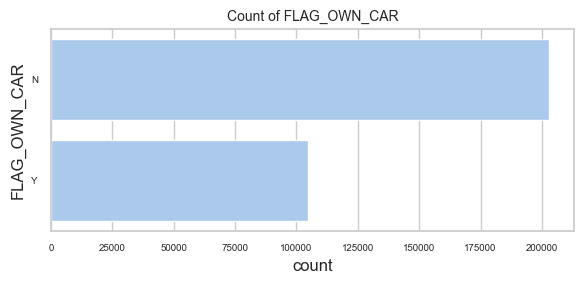

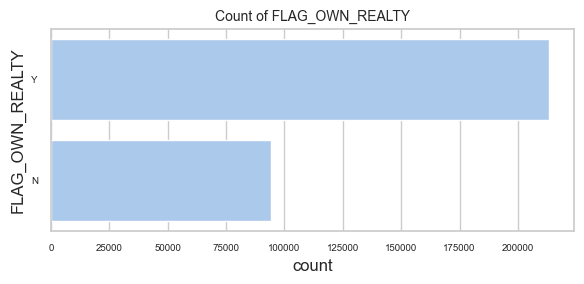

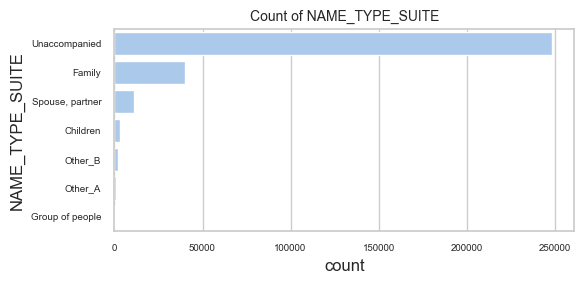

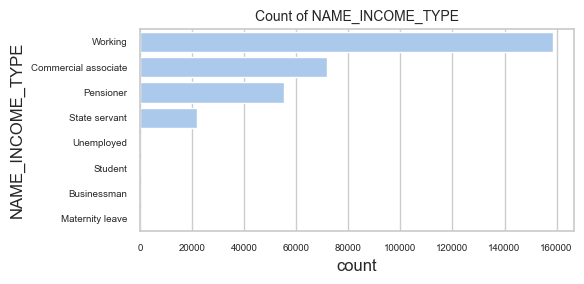

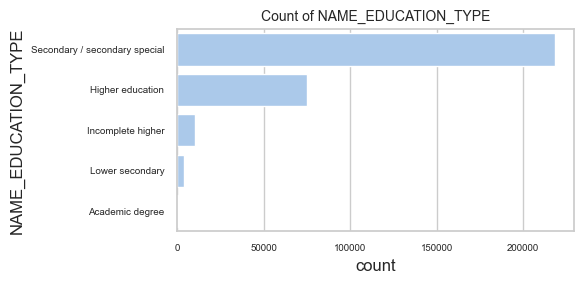

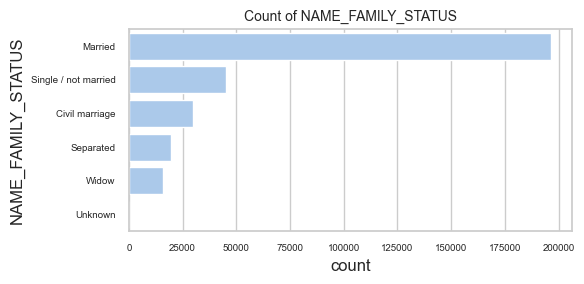

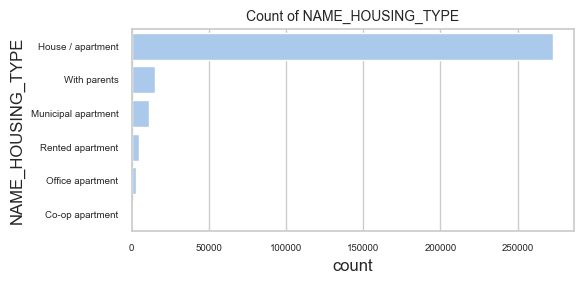

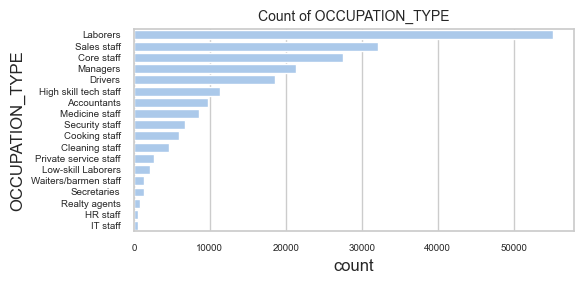

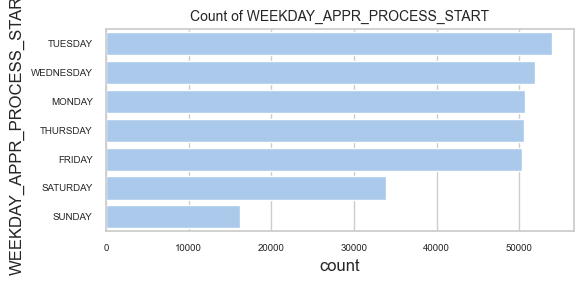

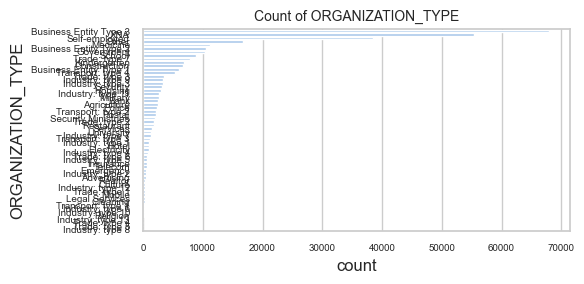

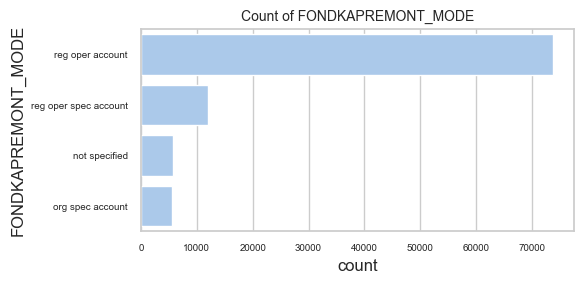

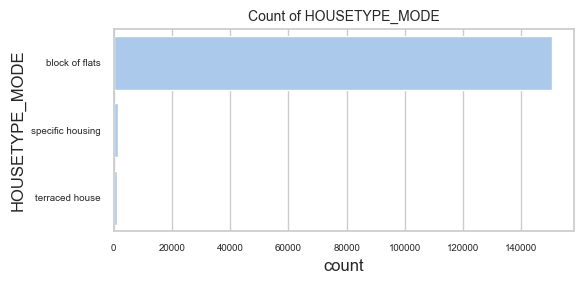

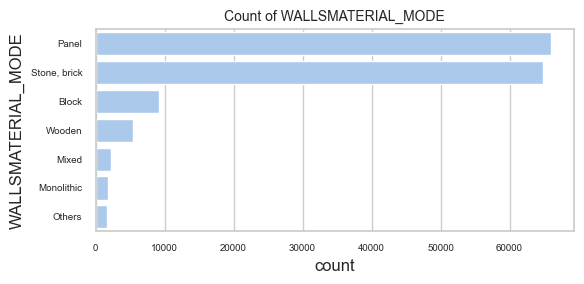

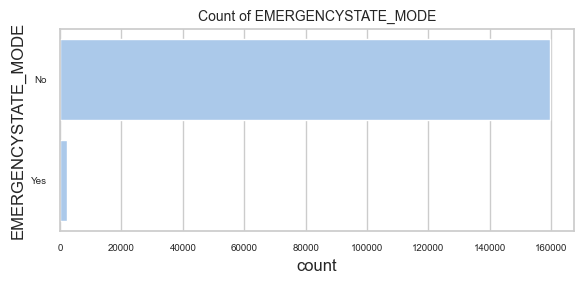

In [15]:
for col in text_fields:
    plt.figure(figsize=(6,3))
    sns.countplot(
        data=df_train,
        y=col,
        order=df_train[col].value_counts().index
    )
    plt.title(f'Count of {col}', fontsize=10)
    plt.xticks(fontsize=7)
    plt.yticks(fontsize=7)
    plt.tight_layout()
    plt.show()


## Anomaly exploration in data.  Anomaly Detection, Validation, and Treatment (EDA → Modeling)

Age --> 

In [14]:
# Step 1. Detecting the suspicious values
df_train.describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,278180.518577,102790.175348,100002.0,189145.5,278202.0,367142.5,456255.0
TARGET,307511.0,0.080729,0.272419,0.0,0.0,0.0,0.0,1.0
CNT_CHILDREN,307511.0,0.417052,0.722121,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0
...,...,...,...,...,...,...,...,...
AMT_REQ_CREDIT_BUREAU_DAY,265992.0,0.007000,0.110757,0.0,0.0,0.0,0.0,9.0
AMT_REQ_CREDIT_BUREAU_WEEK,265992.0,0.034362,0.204685,0.0,0.0,0.0,0.0,8.0
AMT_REQ_CREDIT_BUREAU_MON,265992.0,0.267395,0.916002,0.0,0.0,0.0,0.0,27.0
AMT_REQ_CREDIT_BUREAU_QRT,265992.0,0.265474,0.794056,0.0,0.0,0.0,0.0,261.0


In [15]:
# Find the correlation of the positive days since birth and target
df_train['DAYS_BIRTH'] = abs(df_train['DAYS_BIRTH'])
df_train['DAYS_BIRTH'].corr(df_train['TARGET'])

np.float64(-0.07823930830982709)

In [16]:
df_numeric = df_train.select_dtypes(include=[np.number]).columns
df_numeric
# for col in df_numeric:
#     print(col)

Index(['SK_ID_CURR', 'TARGET', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
       'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='str', length=106)

In [17]:
desc = df_train[df_numeric].describe().T
desc

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,278180.518577,102790.175348,100002.0,189145.5,278202.0,367142.5,456255.0
TARGET,307511.0,0.080729,0.272419,0.0,0.0,0.0,0.0,1.0
CNT_CHILDREN,307511.0,0.417052,0.722121,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0
...,...,...,...,...,...,...,...,...
AMT_REQ_CREDIT_BUREAU_DAY,265992.0,0.007000,0.110757,0.0,0.0,0.0,0.0,9.0
AMT_REQ_CREDIT_BUREAU_WEEK,265992.0,0.034362,0.204685,0.0,0.0,0.0,0.0,8.0
AMT_REQ_CREDIT_BUREAU_MON,265992.0,0.267395,0.916002,0.0,0.0,0.0,0.0,27.0
AMT_REQ_CREDIT_BUREAU_QRT,265992.0,0.265474,0.794056,0.0,0.0,0.0,0.0,261.0


In [18]:
rules = {
    'AGE': lambda s: (s < 18) | (s > 100),
    'DAYS_BIRTH': lambda s: s > 0,                 # should be negative
    'DAYS_EMPLOYED': lambda s: s > 0,              # suspicious
    'AMT_INCOME_TOTAL': lambda s: s <= 0,
    'AMT_CREDIT': lambda s: s <= 0,
}


In [19]:
impossible_summary = {}

for col, rule in rules.items():
    if col in df_train.columns:
        impossible_summary[col] = rule(df_train[col]).sum()

pd.Series(impossible_summary, name='impossible_count')


DAYS_BIRTH              0
DAYS_EMPLOYED       55374
AMT_INCOME_TOTAL        0
AMT_CREDIT              0
Name: impossible_count, dtype: int64

In [20]:
df_train['DAYS_EMPLOYED'].value_counts().head()


DAYS_EMPLOYED
 365243    55374
-200         156
-224         152
-199         151
-230         151
Name: count, dtype: int64

In [21]:
anom = df_train[df_train['DAYS_EMPLOYED'] > 0]
non_anom = df_train[df_train['DAYS_EMPLOYED'] <= 0]

anom['TARGET'].mean(), non_anom['TARGET'].mean()


(np.float64(0.05399646043269404), np.float64(0.0865997453765215))

In [22]:
desc['p99'] = df_train[df_numeric].quantile(0.99)

desc['max_to_p99_ratio'] = desc['max'] / desc['p99']


In [24]:
desc['max_to_p99_ratio']

SK_ID_CURR                      1.007824
TARGET                          1.000000
CNT_CHILDREN                    6.333333
AMT_INCOME_TOTAL              247.619048
AMT_CREDIT                      2.184466
                                 ...    
AMT_REQ_CREDIT_BUREAU_DAY            inf
AMT_REQ_CREDIT_BUREAU_WEEK      8.000000
AMT_REQ_CREDIT_BUREAU_MON       6.750000
AMT_REQ_CREDIT_BUREAU_QRT     130.500000
AMT_REQ_CREDIT_BUREAU_YEAR      3.125000
Name: max_to_p99_ratio, Length: 106, dtype: float64

In [25]:
desc['p99']

SK_ID_CURR                     452712.9
TARGET                              1.0
CNT_CHILDREN                        3.0
AMT_INCOME_TOTAL               472500.0
AMT_CREDIT                    1854000.0
                                ...    
AMT_REQ_CREDIT_BUREAU_DAY           0.0
AMT_REQ_CREDIT_BUREAU_WEEK          1.0
AMT_REQ_CREDIT_BUREAU_MON           4.0
AMT_REQ_CREDIT_BUREAU_QRT           2.0
AMT_REQ_CREDIT_BUREAU_YEAR          8.0
Name: p99, Length: 106, dtype: float64

In [26]:
gap_cols = desc[desc['max_to_p99_ratio'] > 3] \
            .sort_values('max_to_p99_ratio', ascending=False)

gap_cols[['p99', 'max', 'max_to_p99_ratio']].head(10)


,p99,max,max_to_p99_ratio
FLAG_DOCUMENT_10,0.0,1.0,inf
FLAG_DOCUMENT_11,0.0,1.0,inf
FLAG_DOCUMENT_9,0.0,1.0,inf
FLAG_DOCUMENT_7,0.0,1.0,inf
AMT_REQ_CREDIT_BUREAU_HOUR,0.0,4.0,inf
AMT_REQ_CREDIT_BUREAU_DAY,0.0,9.0,inf
FLAG_DOCUMENT_17,0.0,1.0,inf
FLAG_DOCUMENT_16,0.0,1.0,inf
FLAG_DOCUMENT_2,0.0,1.0,inf
FLAG_DOCUMENT_4,0.0,1.0,inf


In [18]:

age_df = df_train[['TARGET', 'DAYS_BIRTH']]
age_df['YEARS_BIRTH'] = age_df['DAYS_BIRTH'] / 365

age_df['YEARS_BINNED'] = pd.cut(age_df['YEARS_BIRTH'], bins= np.linspace(20, 70, num=11))
age_df.head(15)

,TARGET,DAYS_BIRTH,YEARS_BIRTH,YEARS_BINNED
0,1,9461,25.920548,"(25.0, 30.0]"
1,0,16765,45.931507,"(45.0, 50.0]"
2,0,19046,52.180822,"(50.0, 55.0]"
3,0,19005,52.068493,"(50.0, 55.0]"
4,0,19932,54.608219,"(50.0, 55.0]"
5,0,16941,46.413699,"(45.0, 50.0]"
6,0,13778,37.747945,"(35.0, 40.0]"
7,0,18850,51.643836,"(50.0, 55.0]"
8,0,20099,55.065753,"(55.0, 60.0]"
9,0,14469,39.641096,"(35.0, 40.0]"


In [19]:
age_groups = age_df.groupby('YEARS_BINNED').mean()
age_groups

,TARGET,DAYS_BIRTH,YEARS_BIRTH
YEARS_BINNED,,,
"(20.0, 25.0]",0.123036,8532.795625,23.377522
"(25.0, 30.0]",0.111436,10155.219250,27.822518
"(30.0, 35.0]",0.102814,11854.848377,32.479037
"(35.0, 40.0]",0.089414,13707.908253,37.555913
"(40.0, 45.0]",0.078491,15497.661233,42.459346
"(45.0, 50.0]",0.074171,17323.900441,47.462741
"(50.0, 55.0]",0.066968,19196.494791,52.593136
"(55.0, 60.0]",0.055314,20984.262742,57.491131
"(60.0, 65.0]",0.052737,22780.547460,62.412459


## plotting distribution of age

Text(0, 0.5, 'Count')

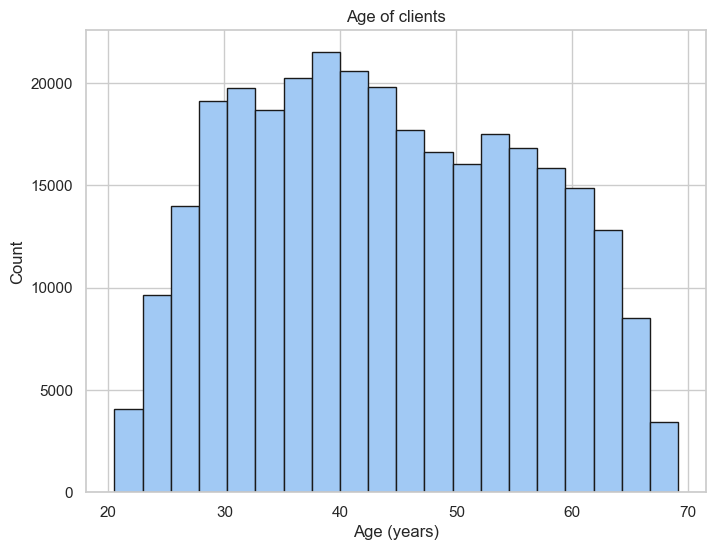

In [20]:
plt.figure(figsize=(8,6))
plt.hist(df_train['DAYS_BIRTH'] / 365, edgecolor='k', bins=20)
plt.title('Age of clients')
plt.xlabel('Age (years)')
plt.ylabel('Count')


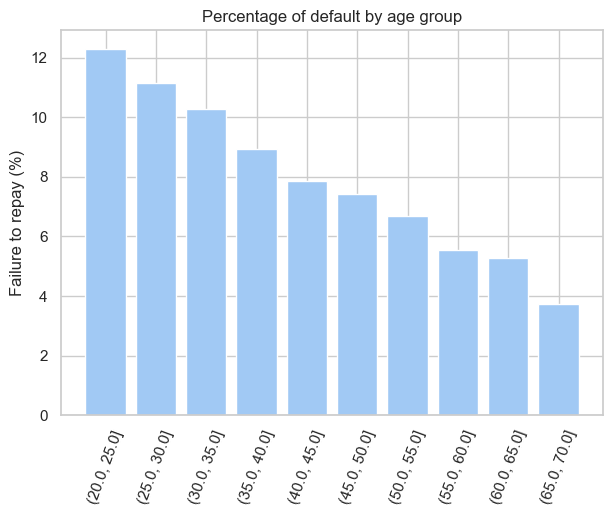

In [21]:
plt.figure(figsize=(7,5))

plt.bar(age_groups.index.astype(str), 100* age_groups['TARGET'])
plt.title('Percentage of default by age group')
plt.xticks(rotation=70)
plt.ylabel("Failure to repay (%)")
plt.show()

### checking the days employed field for anomaly

In [20]:
df_train["DAYS_EMPLOYED"].describe()

count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

so we can see there is anomaly in the days employed. The mean and Max is abnormal

In [21]:
df_train['DAYS_EMPLOYED'] = df_train['DAYS_EMPLOYED'].abs()

In [22]:
df_train['DAYS_EMPLOYED'].replace({365243: np.nan}, inplace=True)

0          637.0
1         1188.0
2          225.0
3         3039.0
4         3038.0
           ...  
307506     236.0
307507       NaN
307508    7921.0
307509    4786.0
307510    1262.0
Name: DAYS_EMPLOYED, Length: 307511, dtype: float64

In [23]:
df_train['DAYS_EMPLOYED'].mean() / 365


np.float64(185.5472387645516)

In [24]:
df_train["DAYS_EMPLOYED"].describe()

count    307511.000000
mean      67724.742149
std      139443.751806
min           0.000000
25%         933.000000
50%        2219.000000
75%        5707.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

### Histogram before handling anomaly of days employement

Text(0.5, 0, 'number of days employed')

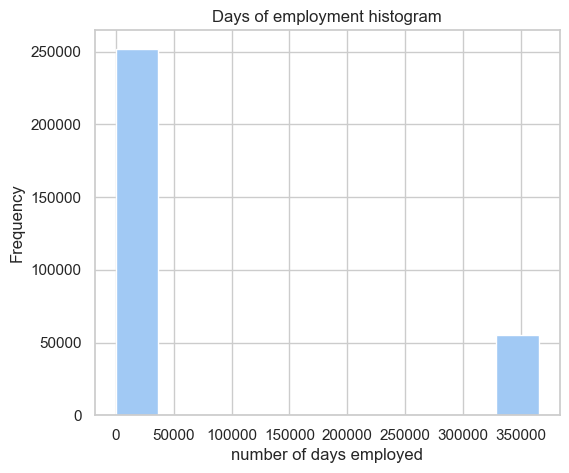

In [27]:
fig, ax = plt.subplots(figsize=(6,5))
df_train['DAYS_EMPLOYED'].plot.hist(title = 'Days of employment histogram')
plt.xlabel('number of days employed')

In [25]:
df_train.loc[df_train['DAYS_EMPLOYED'] == 365243, 'DAYS_EMPLOYED'] = np.nan


In [26]:
df_train['EMPLOYED_ANOM'] = df_train['DAYS_EMPLOYED'] == 365243


In [27]:
df_train['DAYS_EMPLOYED'].replace({365243: np.nan}, inplace=True)


0          637.0
1         1188.0
2          225.0
3         3039.0
4         3038.0
           ...  
307506     236.0
307507       NaN
307508    7921.0
307509    4786.0
307510    1262.0
Name: DAYS_EMPLOYED, Length: 307511, dtype: float64

### Graph after applying anomaly handling. -->

Text(0.5, 0, 'number of days employed')

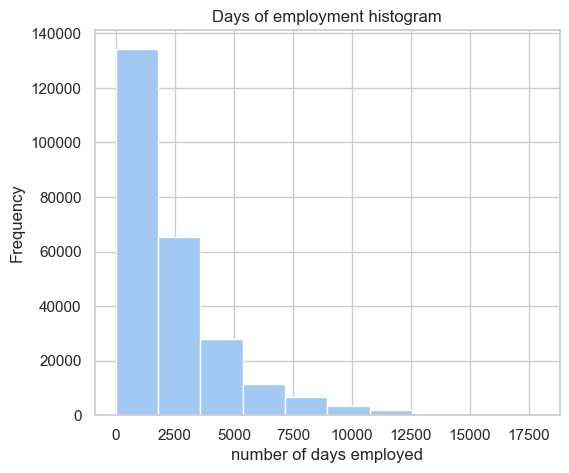

In [28]:
fig, ax = plt.subplots(figsize=(6,5))
df_train['DAYS_EMPLOYED'].plot.hist(title = 'Days of employment histogram')
plt.xlabel('number of days employed')

EXT_SOURCES and DAYS_BIRTH relation

--> All of the ext_sources feature have negative correlations with the target value.

Clients are more likely to repay loan as the value of the EXT_SOURCES increases. 
- Days_Birth is positively correlated with EXT_SOUCE_1, this means that a key factor here is might be the age of the clients


In [29]:
ext_data = df_train[['TARGET', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH']]
ext_data_corrs = ext_data.corr()
ext_data_corrs 

,TARGET,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_BIRTH
TARGET,1.000000,-0.155317,-0.160472,-0.178919,-0.078239
EXT_SOURCE_1,-0.155317,1.000000,0.213982,0.186846,0.600610
EXT_SOURCE_2,-0.160472,0.213982,1.000000,0.109167,0.091996
EXT_SOURCE_3,-0.178919,0.186846,0.109167,1.000000,0.205478
DAYS_BIRTH,-0.078239,0.600610,0.091996,0.205478,1.000000


Text(0.5, 1.0, 'Correlation heatmap of external sources and target')

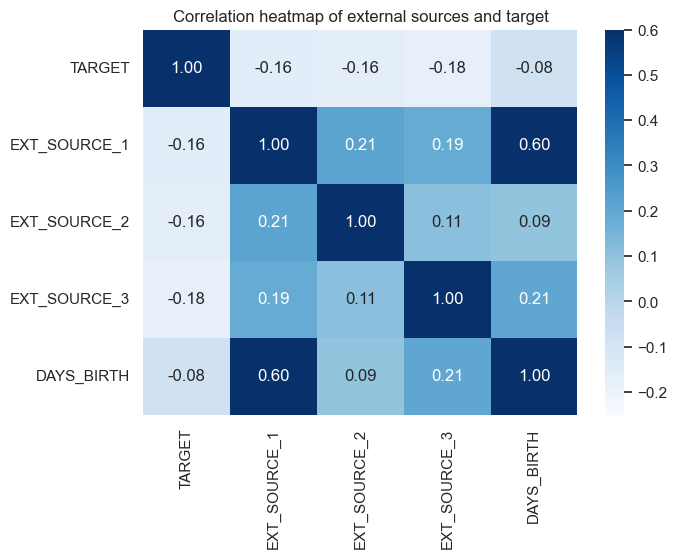

In [33]:
plt.figure(figsize=(7,5))
sns.heatmap(ext_data_corrs, cmap='Blues', annot=True, vmin=-0.25, vmax=0.6, fmt='.2f')
plt.title('Correlation heatmap of external sources and target')

In [30]:
null_sums = df_train.isnull().sum().sort_values(ascending=True)
null_sums


SK_ID_CURR                       0
TARGET                           0
NAME_CONTRACT_TYPE               0
CODE_GENDER                      0
FLAG_OWN_CAR                     0
                             ...  
NONLIVINGAPARTMENTS_AVG     213514
NONLIVINGAPARTMENTS_MEDI    213514
COMMONAREA_MODE             214865
COMMONAREA_AVG              214865
COMMONAREA_MEDI             214865
Length: 123, dtype: int64

## Finding the feature importance from the data using Random forest algorithm


In [31]:
from sklearn import preprocessing
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt

In [58]:
# num_cols = df_train.select_dtypes(include='number').columns
# test_num_cols = test_df.select_dtypes(include='number').columns

# df_train[num_cols] = df_train[num_cols].fillna(-999)
# test_df[test_num_cols] = test_df[test_num_cols].fillna(-999)

In [59]:
# # Fill string/object columns with 'missing'
# obj_cols = df_train.select_dtypes(include='object').columns
# test_obj_cols = test_df.select_dtypes(include='object').columns

# df_train[obj_cols] = df_train[obj_cols].fillna('missing')
# test_df[test_obj_cols] = test_df[test_obj_cols].fillna('missing')

In [32]:
# Step 1: Fill NaN - handle mixed dtypes
num_cols = df_train.select_dtypes(include='number').columns
obj_cols = df_train.select_dtypes(include=['object', 'string']).columns  # added 'string'

test_num_cols = test_df.select_dtypes(include='number').columns
test_obj_cols = test_df.select_dtypes(include=['object', 'string']).columns  # added 'string'

df_train[num_cols] = df_train[num_cols].fillna(-999)
df_train[obj_cols] = df_train[obj_cols].fillna('missing')

test_df[test_num_cols] = test_df[test_num_cols].fillna(-999)
test_df[test_obj_cols] = test_df[test_obj_cols].fillna('missing')

In [ ]:
# Step 3: Label Encode
categorical_features = [f for f in df_train.columns 
                        if df_train[f].dtype == 'object' or pd.api.types.is_string_dtype(df_train[f])]

for col in categorical_features:
    le = preprocessing.LabelEncoder()
    le.fit(list(df_train[col].values) + list(test_df[col].values))
    df_train[col] = le.transform(list(df_train[col].values))
    test_df[col] = le.transform(list(test_df[col].values))

# Step 4: Force all columns to numeric
df_train =  df_train.apply(pd.to_numeric, errors='coerce')
test_df = test_df.apply(pd.to_numeric, errors='coerce')

# Step 5: Check - should print empty list
print("Remaining non-numeric columns:", df_train.select_dtypes(include=['object','string']).columns.tolist())


Remaining non-numeric columns: []


In [ ]:
df_train

In [ ]:
# from sklearn import preprocessing
# # Step 2: Label Encode - also catch 'string' dtype columns
# categorical_features = [f for f in df_train.columns 
#                         if df_train[f].dtype == 'object' or df_train[f].dtype.name == 'string']


# for col in categorical_features:
#     le = preprocessing.LabelEncoder()

#     le.fit(list(df_train[col].values.astype('str')) + list(test_df[col].values.astype('str')))

#     df_train[col] = le.transform(list(df_train[col].values.astype('str')))

#     test_df[col] = le.transform(list(test_df[col].values.astype('str')))



In [35]:
# Step 3: Quick check - no string columns should remain
print("Remaining non-numeric columns:", df_train.select_dtypes(include=['object','string']).columns.tolist())

Remaining non-numeric columns: []


In [36]:
# Step 3: Define features and target
X = df_train.drop(['SK_ID_CURR', 'TARGET'], axis=1)
y = df_train['TARGET']

In [37]:
rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=8,
    min_samples_leaf=4,
    max_features=0.5,
    random_state=2018
)
rf.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",0.5
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_true

In [38]:
# Extract and display feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns.values,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance.head(20))

                        feature  importance
40                 EXT_SOURCE_2    0.338745
41                 EXT_SOURCE_3    0.310033
39                 EXT_SOURCE_1    0.072724
15                   DAYS_BIRTH    0.045852
16                DAYS_EMPLOYED    0.020350
11          NAME_EDUCATION_TYPE    0.017945
1                   CODE_GENDER    0.012567
18              DAYS_ID_PUBLISH    0.012255
6                    AMT_CREDIT    0.012249
7                   AMT_ANNUITY    0.011789
8               AMT_GOODS_PRICE    0.011602
17            DAYS_REGISTRATION    0.011043
93       DAYS_LAST_PHONE_CHANGE    0.007794
10             NAME_INCOME_TYPE    0.007307
38            ORGANIZATION_TYPE    0.006279
5              AMT_INCOME_TOTAL    0.004937
14   REGION_POPULATION_RELATIVE    0.004735
95              FLAG_DOCUMENT_3    0.003918
119  AMT_REQ_CREDIT_BUREAU_YEAR    0.003340
19                  OWN_CAR_AGE    0.003190


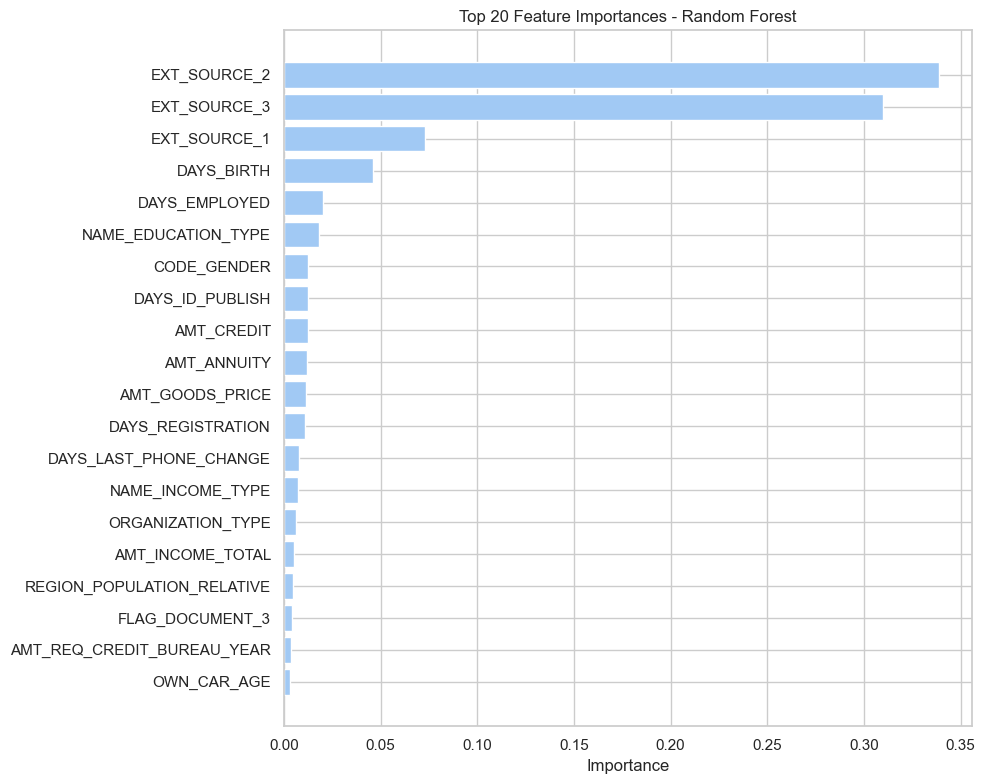

In [39]:

# Step 9: Plot
plt.figure(figsize=(10, 8))
plt.barh(
    feature_importance['feature'].head(20)[::-1],
    feature_importance['importance'].head(20)[::-1]
)
plt.xlabel('Importance')
plt.title('Top 20 Feature Importances - Random Forest')
plt.tight_layout()
plt.show()

In [ ]:
# Finding cumulative importance alogn with feature importance
feature_importance['cumulative_importance'] = feature_importance['importance'].cumsum()
print(feature_importance.head(30))

                         feature  importance  cumulative_importance
40                  EXT_SOURCE_2    0.338745               0.338745
41                  EXT_SOURCE_3    0.310033               0.648778
39                  EXT_SOURCE_1    0.072724               0.721502
15                    DAYS_BIRTH    0.045852               0.767353
16                 DAYS_EMPLOYED    0.020350               0.787703
11           NAME_EDUCATION_TYPE    0.017945               0.805648
1                    CODE_GENDER    0.012567               0.818215
18               DAYS_ID_PUBLISH    0.012255               0.830471
6                     AMT_CREDIT    0.012249               0.842720
7                    AMT_ANNUITY    0.011789               0.854509
8                AMT_GOODS_PRICE    0.011602               0.866112
17             DAYS_REGISTRATION    0.011043               0.877155
93        DAYS_LAST_PHONE_CHANGE    0.007794               0.884949
10              NAME_INCOME_TYPE    0.007307    

Now selecting the features based on the feature importance! 
- using cumulative importance as threshold so that I don't miss any important features with less feature importance that has impact on the datset.

In [43]:
selected_features = feature_importance[
    feature_importance['cumulative_importance'] <= 0.95
]['feature'].tolist()

print(f"Selected features that contribute to 95% of importance: {selected_features}")
print("len of selected features: ", len(selected_features))

Selected features that contribute to 95% of importance: ['EXT_SOURCE_2', 'EXT_SOURCE_3', 'EXT_SOURCE_1', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'NAME_EDUCATION_TYPE', 'CODE_GENDER', 'DAYS_ID_PUBLISH', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'DAYS_REGISTRATION', 'DAYS_LAST_PHONE_CHANGE', 'NAME_INCOME_TYPE', 'ORGANIZATION_TYPE', 'AMT_INCOME_TOTAL', 'REGION_POPULATION_RELATIVE', 'FLAG_DOCUMENT_3', 'AMT_REQ_CREDIT_BUREAU_YEAR', 'OWN_CAR_AGE', 'HOUR_APPR_PROCESS_START', 'DEF_60_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE', 'TOTALAREA_MODE', 'OCCUPATION_TYPE', 'OBS_60_CNT_SOCIAL_CIRCLE', 'REGION_RATING_CLIENT_W_CITY', 'OBS_30_CNT_SOCIAL_CIRCLE', 'YEARS_BEGINEXPLUATATION_AVG', 'FLAG_EMP_PHONE', 'YEARS_BEGINEXPLUATATION_MEDI', 'LIVINGAREA_MEDI', 'LANDAREA_AVG', 'LANDAREA_MODE', 'REG_CITY_NOT_LIVE_CITY']
len of selected features:  35


### Starting model training on Light GBM

In [44]:
x_selected = df_train[selected_features]
x_test_selected = test_df[selected_features]


In [45]:
y = df_train['TARGET']

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (roc_auc_score, roc_curve, classification_report, 
                             confusion_matrix, ConfusionMatrixDisplay)

X_train, X_val, y_train, y_val = train_test_split(
    x_selected, y, test_size=0.2, random_state=42, stratify=y  
)

print(f"Train size: {X_train.shape}, Validation size: {X_val.shape}")

Train size: (246008, 35), Validation size: (61503, 35)


### Defining the models

In [47]:
import lightgbm as lgb
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
models = {
    'LigthGBM':lgb.LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        is_unbalance=True,   # handles class imbalance (92% vs 8%)
        random_state=42
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        scale_pos_weight=11.5,  # handles class imbalance
        random_state=42
    ),
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        class_weight='balanced',  # handles class imbalance
        random_state=42
    )
}

In [48]:
# now need scaling for logistic regression as it does not handle large feature values well,
# while tree-based models do not require scaling.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)


[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015598 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4756
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482

Model: LigthGBM
ROC-AUC Score: 0.7582

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.72      0.83     56538
           1       0.17      0.65      0.27      4965

    accuracy                           0.72     61503
   macro avg       0.57      0.69      0.55     61503
weighted avg       0.90      0.72      0.78     61503


Model: XGBoost
ROC-AUC Score: 0.7559

Classificat

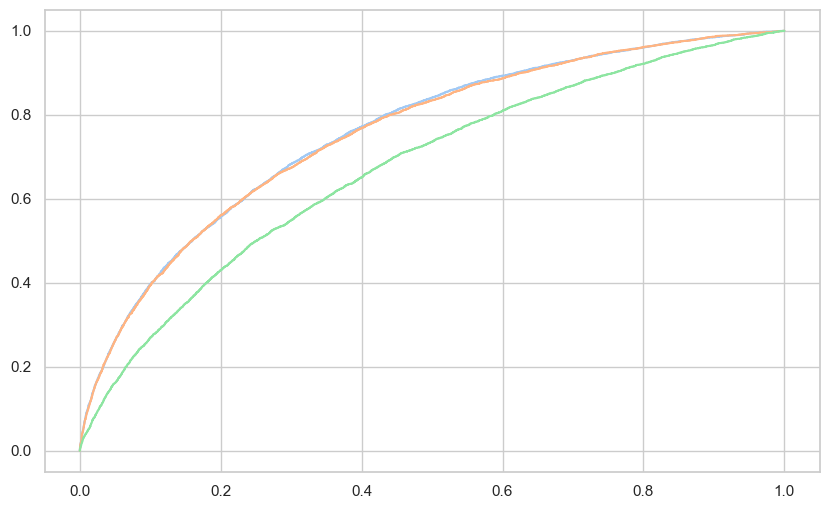

In [ ]:
results = {}
plt.figure(figsize=(10, 6))

for name, model in models.items():
    #  scaled data for Logistic Regression
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred_proba = model.predict_proba(X_val_scaled)[:, 1]
        y_pred = model.predict(X_val_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred_proba = model.predict_proba(X_val)[:, 1]
        y_pred = model.predict(X_val)

    # ROC-AUC Score
    auc = roc_auc_score(y_val, y_pred_proba)
    results[name] = auc
    print(f"\n{'='*40}")
    print(f"Model: {name}")
    print(f"ROC-AUC Score: {auc:.4f}")
    print(f"\nClassification Report:\n{classification_report(y_val, y_pred)}")

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_val, y_pred_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})")


# Final Model Improvements
This section adds:

- Class imbalance handling using **SMOTE**
- **Hyperparameter tuning** with GridSearchCV
- **Confusion Matrix**
- **ROC Curve**
- **Feature Importance**
- Final **model evaluation**


## 1. Handle Class Imbalance with SMOTE

In [ ]:

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_bal.value_counts())


## 2. Hyperparameter Tuning (LightGBM)

In [ ]:

import lightgbm as lgb
from sklearn.model_selection import GridSearchCV

model = lgb.LGBMClassifier(random_state=42)

param_grid = {
    "n_estimators": [200, 400],
    "learning_rate": [0.01, 0.05],
    "num_leaves": [31, 50],
    "max_depth": [-1, 10]
}

grid = GridSearchCV(
    model,
    param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_bal, y_train_bal)

best_model = grid.best_estimator_
print("Best Parameters:", grid.best_params_)


## 3. Train Final Model

In [ ]:

best_model.fit(X_train_bal, y_train_bal)

y_pred = best_model.predict(X_val)
y_prob = best_model.predict_proba(X_val)[:,1]


## 4. Confusion Matrix

In [ ]:

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()


## 5. ROC Curve

In [ ]:

from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_val, y_prob)
auc = roc_auc_score(y_val, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()


## 6. Feature Importance

In [ ]:

import pandas as pd
import seaborn as sns

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_model.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,8))

sns.barplot(
    data=importance.head(20),
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Feature Importance")
plt.show()


## 7. Final Model Performance

In [ ]:

from sklearn.metrics import classification_report

print("ROC-AUC Score:", roc_auc_score(y_val, y_prob))

print("\nClassification Report:\n")
print(classification_report(y_val, y_pred))
